# Vanilla MatchFormer Failure Analysis
Demonstrating how the unconstrained Vanilla MatchFormer model fails on ambiguous query points, and plotting the true Ground Truth target point derived from the 3D depth maps.

In [1]:
%matplotlib inline
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

from config.defaultmf import get_cfg_defaults
from model.lightning_loftr import PL_LoFTR
from match_poses import read_trajectory, get_pose_for_image
from gt_epipolar import compute_fundamental_matrix, K

config = get_cfg_defaults()
config.MATCHFORMER.BACKBONE_TYPE = 'litela'
config.MATCHFORMER.SCENS = 'indoor'
config.MATCHFORMER.RESOLUTION = (8, 4)
config.MATCHFORMER.COARSE.D_MODEL = 192
config.MATCHFORMER.COARSE.D_FFN = 192

model_vanilla = PL_LoFTR(config, pretrained_ckpt='model/weights/indoor-lite-LA.ckpt').eval()

HW_layer_map = {'stage4_cross': (15, 20)}

def get_cross_attn_hook(name, layer, ux, uy, store_dict):
    def hook(model, input, output):
        x = input[0]
        B, N, C = x.shape
        MiniB = B // 2
        query = layer.q(x).reshape(B, N, layer.num_heads, C // layer.num_heads).permute(0, 1, 2, 3)
        kv = layer.kv(x).reshape(B, -1, 2, layer.num_heads, C // layer.num_heads).permute(2, 0, 1, 3, 4)
        if layer.cross:
            k1, k2 = kv[0].split(MiniB)
            key = torch.cat([k2, k1], dim=0) 
        else: return 
        
        Q = layer.feature_map(query).permute(0, 2, 1, 3) 
        K = layer.feature_map(key).permute(0, 2, 1, 3)
        H_feat, W_feat = HW_layer_map[name]
        feat_x = int((ux / 640.0) * W_feat)
        feat_y = int((uy / 480.0) * H_feat)
        query_idx = feat_y * W_feat + feat_x

        Q_single = Q[0, :, query_idx:query_idx+1, :] 
        K_targets = K[0, :, :, :]
        attn = torch.matmul(Q_single, K_targets.transpose(-2, -1))
             
        Z = 1 / (attn.sum(dim=-1, keepdim=True) + layer.eps)
        attn_final = attn * Z
        store_dict[name] = attn_final.mean(dim=0).squeeze(0).detach().cpu()
    return hook

rgb_dir = '../tum_rgb_dataset/rgb/*.png'
all_imgs = sorted(glob.glob(rgb_dir))
gt_file = '../tum_rgb_dataset/groundtruth.txt'
poses = read_trajectory(gt_file)

depth_dir = '../tum_rgb_dataset/depth/'

def get_image(path, resize=(640, 480)):
    img_rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, resize)
    img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    img_tensor = torch.from_numpy(img).float() / 255.0
    img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)
    return img_rgb, img_tensor

def get_depth_map(rgb_path):
    # TUM pairs rgb and depth by closest timestamp. We can usually just find the matching depth file via associations,
    # but for simplicity let's assume the tum dataset has depth maps saved with identical timestamps or we can just glob nearest.
    # We will just load the exact corresponding depth file if filename match exists (adjust logic if your tum folder structure differs)
    
    # Actually, a safer way to get the true projection:
    base = os.path.basename(rgb_path)
    # the depth dir should contain identical filenames if perfectly synced, or we read a sync file.
    # TUM sync maps depth timestamps to rgb. Let's list depth dir and just grab the closest numeric timestamp.
    rgb_ts = float(base.replace('.png', ''))
    depth_files = os.listdir(depth_dir)
    best_depth = min(depth_files, key=lambda f: abs(float(f.replace('.png', '')) - rgb_ts))
    
    depth_img = cv2.imread(os.path.join(depth_dir, best_depth), cv2.IMREAD_UNCHANGED)
    # TUM depth factor is usually 5000: Z = depth / 5000.0
    # The depth map size isn't always 640x480 perfectly aligned without calibration, but we resize for this viz.
    # Better to keep original mapping
    return depth_img

def project_point_to_target(ux, uy, depth_map, T1, T2, K_mat=K):
    # Z from TUM is stored in 16bit PNG, scale by 5000
    # Get depth at original pixel
    # Depth maps may not perfectly match RGB size, we assume 640x480 alignment
    h_d, w_d = depth_map.shape
    dx = int(ux * (w_d / 640.0))
    dy = int(uy * (h_d / 480.0))
    
    depth_val = depth_map[dy, dx]
    if depth_val == 0:
        return None  # No valid depth here
        
    Z = depth_val / 5000.0  # meters
    
    # 2D to 3D Camera Coordinate
    cx, cy = K_mat[0, 2], K_mat[1, 2]
    fx, fy = K_mat[0, 0], K_mat[1, 1]
    
    X = (dx - cx) * Z / fx
    Y = (dy - cy) * Z / fy
    P_cam1 = np.array([X, Y, Z, 1.0])
    
    # World Coordinates
    P_world = np.linalg.inv(T1) @ P_cam1
    
    # Cam2 Coordinates
    P_cam2 = T2 @ P_world
    
    # Cam2 to 2D Pixel
    if P_cam2[2] <= 0: return None # Behind camera
    
    u2 = (P_cam2[0] * fx / P_cam2[2]) + cx
    v2 = (P_cam2[1] * fy / P_cam2[2]) + cy
    
    return np.array([u2, v2])

def compute_ear(attn_prob, a, b, c, k_pixels):
    H, W = attn_prob.shape
    y, x = np.mgrid[0:H, 0:W]
    distances = np.abs(a*x + b*y + c) / np.sqrt(a**2 + b**2)
    mask = distances <= k_pixels
    return np.sum(attn_prob[mask])

def draw_epipolar_line(ax, a, b, c, w=640, h=480):
    x0, x1 = 0, w
    y0 = int(-(a*x0 + c) / b)
    y1 = int(-(a*x1 + c) / b)
    ax.plot([x0, x1], [y0, y1], 'w--', linewidth=2, label='Epipolar Line')

def plot_failure_pair(img1_idx, img2_idx, query_points):
    img1_path = all_imgs[img1_idx]
    img2_path = all_imgs[img2_idx]
    img1_rgb, img1_tensor = get_image(img1_path)
    img2_rgb, img2_tensor = get_image(img2_path)
    
    T1 = get_pose_for_image(img1_path, poses)
    T2 = get_pose_for_image(img2_path, poses)
    if T1 is None or T2 is None: return
    F = compute_fundamental_matrix(T1, T2, K, K)
    
    depth1 = get_depth_map(img1_path)
    
    input_data_v = {'image0': img1_tensor, 'image1': img2_tensor}
    
    for (pt_name, (ux, uy)) in query_points.items():
        vanilla_attn = {}
        
        # Hooks
        h_v = model_vanilla.matcher.backbone.AttentionBlock4.block[2].attn.register_forward_hook(
            get_cross_attn_hook('stage4_cross', model_vanilla.matcher.backbone.AttentionBlock4.block[2].attn, ux, uy, vanilla_attn)
        )
        
        with torch.no_grad():
            model_vanilla.matcher(input_data_v)
            
        h_v.remove()
        
        # Ground Truth Calculation
        gt_pt = project_point_to_target(ux, uy, depth1, T1, T2, K)
        
        # Math Epipolar
        p = np.array([ux, uy, 1.0])
        l_prime = F @ p 
        a, b, c = l_prime
        
        H_feat, W_feat = HW_layer_map['stage4_cross']
        
        heat_v = vanilla_attn['stage4_cross'].reshape(H_feat, W_feat).numpy()
        heat_v_rez = cv2.resize(heat_v, (640, 480))
        heat_v_norm = (heat_v_rez - heat_v_rez.min()) / (heat_v_rez.max() - heat_v_rez.min() + 1e-8)
        ear_v = compute_ear(heat_v_rez / np.sum(heat_v_rez), a, b, c, 10)
        max_idx_v = np.unravel_index(np.argmax(heat_v_rez), heat_v_rez.shape)
        pred_v = np.array([max_idx_v[1], max_idx_v[0]])
        
        # ----- PLOTTING -----
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # 1. Source
        axes[0].imshow(img1_rgb)
        axes[0].plot(ux, uy, 'r*', markersize=15, label="Query Point")
        axes[0].set_title(f"Source Image\nQuery: {pt_name}")
        axes[0].axis('off')
        axes[0].legend()
        
        # 2. Vanilla
        axes[1].imshow(img2_rgb)
        axes[1].imshow(heat_v_norm, cmap='jet', alpha=0.5)
        draw_epipolar_line(axes[1], a, b, c)
        
        dist_v = np.abs(a*pred_v[0] + b*pred_v[1] + c) / np.sqrt(a**2 + b**2)
        color = 'g*' if dist_v < 5.0 else 'rx'
        axes[1].plot(pred_v[0], pred_v[1], color, markersize=14, label=f'Vanilla Pred (Err: {dist_v:.1f}px)')
        
        if gt_pt is not None:
             axes[1].plot(gt_pt[0], gt_pt[1], 'b*', markersize=18, mec='white', mew=2, label='TRUE MATCH (GT)')
             
        axes[1].set_title(f"Vanilla Target Attention\nEAR: {ear_v:.4f}")
        axes[1].legend(loc='lower right')
        axes[1].set_xlim([0, 640]); axes[1].set_ylim([480, 0])
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()

print("Setup Complete.")


/Users/siddharthraj/classes/cv/final-proj/env/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


2026-03-13 13:58:39.115 | INFO     | model.lightning_loftr:__init__:34 - Load 'model/weights/indoor-lite-LA.ckpt' as pretrained checkpoint


Setup Complete.


## Failure Cases Test with Ground Truth

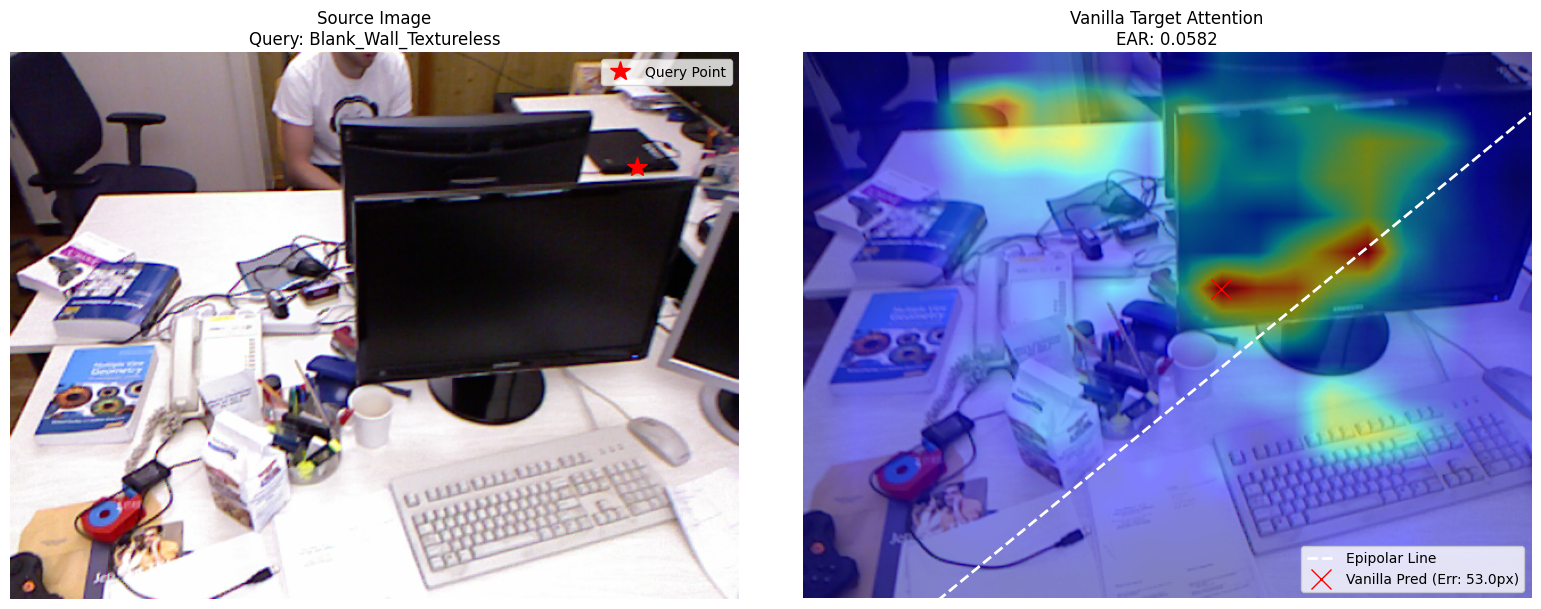

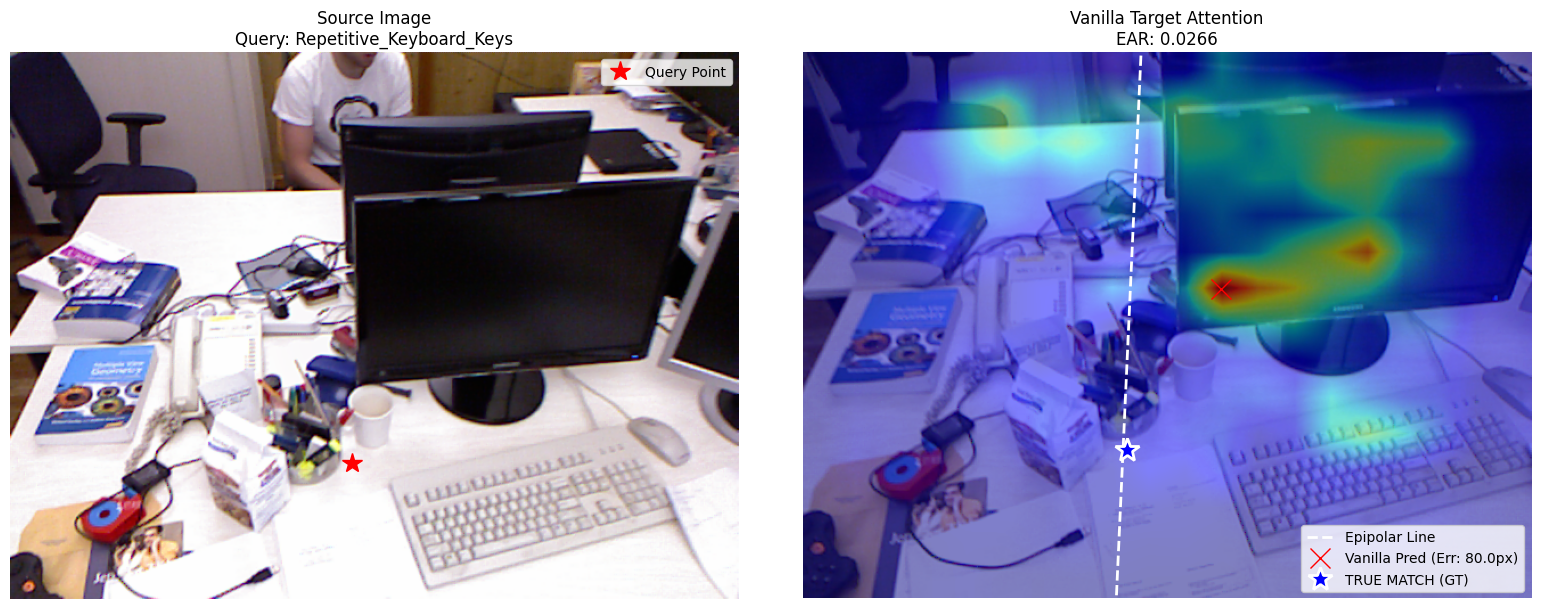

In [2]:
test_points = {
    'Blank_Wall_Textureless': (550, 100),
    'Repetitive_Keyboard_Keys': (300, 360)
}
plot_failure_pair(0, 10, test_points)
